# 1 month salt budget test for ACCESS control, shelf only

Trying to see whether salinity change on shelf is primarily from advection vs surface fluxes.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output040/ocean/ocean.nc'))
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output040/ocean/ocean_month.nc'))

In [3]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['pme_river','runoff','evap','pme_correct']].sel(yt_ocean=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['salt','salt_advection','salt_submeso','salt_tendency','salt_vdiffuse_impl','salt_nonlocal_KPP','salt_rivermix','salt_eta_smooth']].sel(yt_ocean=lat_slice)
    return ds

data_1 = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto')
data_2 = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto')

In [4]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [5]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

In [6]:
lhs_salt = {
    'salt_tendency': data_2.salt_tendency
}

rhs_salt = {
    # Advection
    'advection': data_2.salt_advection,
    'submeso': data_2.salt_submeso,

    # Diffusion / mixing + Surface & boundary forcing
    'vertical_diff': data_2.salt_vdiffuse_impl, # this includes surface salt flux
    'nonlocal_KPP': data_2.salt_nonlocal_KPP,
    'river_mix': data_2.salt_rivermix,
    'eta_smooth': data_2.salt_eta_smooth, # surface smoother for salt
}

In [7]:
data_2

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 1, st_ocean: 75, yt_ocean: 460, xt_ocean: 3600)
Coordinates:
  * time                (time) object 8B 1910-01-16 12:00:00
  * st_ocean            (st_ocean) float64 600B 0.5413 1.681 ... 5.709e+03
  * yt_ocean            (yt_ocean) float64 4kB -79.0 -78.95 ... -59.08 -59.03
  * xt_ocean            (xt_ocean) float64 29kB -279.9 -279.8 ... 79.85 79.95
Data variables:
    salt                (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_advection      (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_submeso        (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_tendency       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_vdiffuse_impl  (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_nonlocal_KPP   (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_rivermix       (time, st_ocean, yt_ocean, xt_ocean) float32 497MB dask.array<chunksize=(1, 75, 460, 720), meta=np.ndarray>
    salt_eta_smooth     (time, yt_ocean, xt_ocean) float32 7MB dask.array<chunksize=(1, 460, 3600), meta=np.ndarray>
Attributes:
    filename:   ocean.nc
    title:      ACCESS-OM2-01
    grid_type:  mosaic
    grid_tile:  1
    history:    20260312T0452Z: /g/data/ik11/inputs/access-om2/bin/mppnccombi...

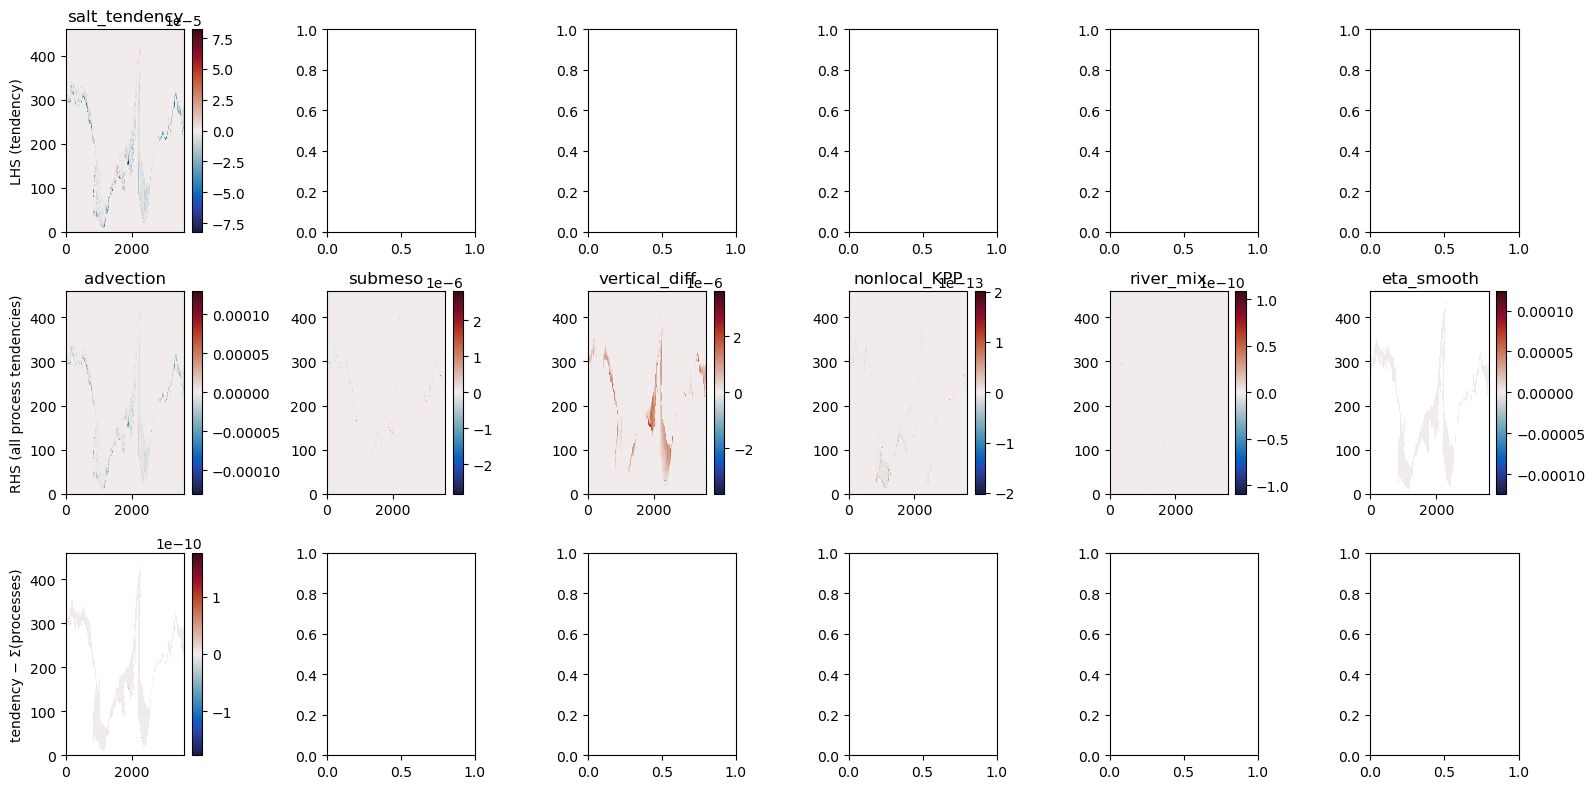

In [8]:
zdim = 'st_ocean'  # MOM6 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    da2d = da_masked.sum(zdim).squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[0, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):

    da_masked = da.where(shelf_mask == 1)

    if zdim in da.dims:
        da2d = da_masked.sum(zdim)
    else:
        da2d = da_masked
    
    da2d = da2d.squeeze()

    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)

    da2d = da2d.compute()

    vmax = np.nanmax(np.abs(da2d))

    im = ax[1, i].pcolormesh(
        da2d, cmap=cm.cm.balance,
        vmax=vmax, vmin=-vmax
    )

    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)


# -----------------------
# Closure residual
# -----------------------
lhs_total = data_2.salt_tendency

# Sum only 3D terms
lhs_col = lhs_total.sum(zdim)

rhs_col = (
    data_2.salt_advection.sum(zdim)
    + data_2.salt_submeso.sum(zdim)
    + data_2.salt_vdiffuse_impl.sum(zdim)
    + data_2.salt_nonlocal_KPP.sum(zdim)
    + data_2.salt_rivermix.sum(zdim)
)

# Now add the 2D correction ONCE
rhs_col = rhs_col + data_2.salt_eta_smooth

residual = lhs_col.where(shelf_mask == 1) - rhs_col.where(shelf_mask == 1)

if 'time' in residual.dims:
    residual = residual.isel(time=0)

residual = residual.compute()

vmax = np.abs(residual).max()

im = ax[2, 0].pcolormesh(
    residual, cmap=cm.cm.balance,
    vmin=-vmax, vmax=vmax
)

plt.colorbar(im, ax=ax[2, 0])

# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()


#### Checking if we have closure:   
We are told that for the budget to be considered “closed” the difference between the LHS and RHS should be approximately 12 orders of magnitude smaller than the contributing terms.   
We also want to check whether there is off-shelf advection.  

In [9]:
# Note residual = (lhs_total - rhs_total).sum(zdim).squeeze()
residual

<xarray.DataArray (yt_ocean: 460, xt_ocean: 3600)> Size: 7MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      object 8B 1910-01-16 12:00:00
    geolon_t  (yt_ocean, xt_ocean) float32 7MB nan nan nan ... 79.75 79.85 79.95
    geolat_t  (yt_ocean, xt_ocean) float32 7MB nan nan nan ... -59.03 -59.03

In [10]:
residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(1.00953912e-10)
Coordinates:
    time     object 8B 1910-01-16 12:00:00

In [11]:
residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(-1.76441972e-10)
Coordinates:
    time     object 8B 1910-01-16 12:00:00

So budget is kind of closed? 
Can we approximate to **tendency = advection + surface forcing**? Check relative magnitude of LHS terms. 

In [12]:
# testing individual diagnostics
tendency = data_2.salt_tendency
advection = data_2.salt_advection
submeso = data_2.salt_submeso
vert_diff_surface = data_2.salt_vdiffuse_impl
nonlocal_KPP = data_2.salt_nonlocal_KPP
river_mix = data_2.salt_rivermix
eta_smooth = data_2.salt_eta_smooth

In [13]:
tendency_plot = tendency.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
advection_plot = advection.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
submeso_plot = submeso.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
vert_diff_surface_plot = vert_diff_surface.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
nonlocal_KPP_plot = nonlocal_KPP.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
river_mix_plot = river_mix.isel(time=0).where(shelf_mask == 1).sum(zdim).squeeze()
eta_smooth_plot = eta_smooth.isel(time=0).where(shelf_mask == 1)

In [14]:
tendency_plot = tendency_plot.compute()
advection_plot = advection_plot.compute()
submeso_plot = submeso_plot.compute()
vert_diff_surface_plot = vert_diff_surface_plot.compute()

In [15]:
nonlocal_KPP_plot = nonlocal_KPP_plot.compute()
river_mix_plot = river_mix_plot.compute()
eta_smooth_plot = eta_smooth_plot.compute()

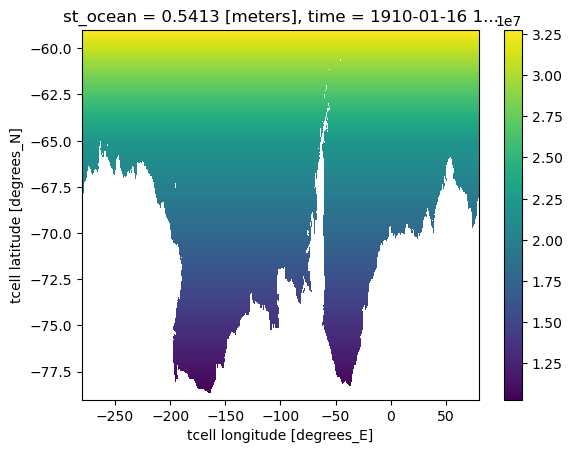

In [16]:
# Doing spatial average
area = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['area_t']
var = data_2.salt.isel(time=0,st_ocean=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [17]:
tendency_ave = (area_corr * tendency_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
advection_ave = (area_corr * advection_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
submeso_ave = (area_corr * submeso_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
vert_diff_surface_ave = (area_corr * vert_diff_surface_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
nonlocal_KPP_ave = (area_corr * nonlocal_KPP_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
river_mix_ave = (area_corr * river_mix_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
eta_smooth_ave = (area_corr * eta_smooth_plot).sum(['xt_ocean', 'yt_ocean']) / area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])

In [18]:
tendency_ave = tendency_ave.load()
advection_ave = advection_ave.load()
submeso_ave = submeso_ave.load()
vert_diff_surface_ave = vert_diff_surface_ave.load()
nonlocal_KPP_ave = nonlocal_KPP_ave.load()
river_mix_ave = river_mix_ave.load()
eta_smooth_ave = eta_smooth_ave.load()

**On average, how much salt per square metre is being added/removed from the shelf (full-depth integrated), due to...**

In [19]:
print("tendency =", tendency_ave.values, "\nadvection =", advection_ave.values, "\nsubmeso =", submeso_ave.values, "\nvertical diffusion and surface forcing =", 
      vert_diff_surface_ave.values, "\nnonlocal KPP =", nonlocal_KPP_ave.values, "\nriver mixing =", river_mix_ave.values, "\neta smoothing =", eta_smooth_ave.values)

tendency = -5.3658687e-06 
advection = -5.7858183e-06 
submeso = -6.483168e-11 
vertical diffusion and surface forcing = 4.3215172e-07 
nonlocal KPP = -1.7239344e-17 
river mixing = -2.762257e-15 
eta smoothing = -1.2137387e-08


So yes, tendency, horizontal advection, and surface forcing are the dominant terms.  
Also eta smoothing having some notable impact?  
We also see that the tendency is dominated by horizontal advection, far more than surface forcing